# 03. Risk model, scenarios and recommendations

**Week 3 deliverable.**

Notebooks 01 and 02 established what is wrong. This one is about what to do, which means
three things leadership can actually act on:

1. **Can a bad review be seen coming** early enough to intervene? (§1)
2. **What should happen to each seller**: invest, coach, or remove? (§2)
3. **What would each fix cost, and what would it buy?** (§3)

A note on what this notebook is *not*. The model in section 1 is not the deliverable, and
we are not proposing to ship it. It exists to rank the drivers and to test whether risk is
concentrated enough to act on in advance. Being clear about that up front matters, because
its headline accuracy number is modest and we want to explain why that is the correct
result rather than a disappointing one.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import plotly.io as pio

from src import analysis as A, viz as V, simulate as S, config as C

pio.renderers.default = "png+plotly_mimetype"

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)

base = A.analysis_base(A.load_facts())
baseline = float(base.is_bad_review.mean())
print(f'{len(base):,} orders   |   baseline detractor rate {baseline:.2%}')

95,560 orders   |   baseline detractor rate 12.79%


---
# 1. Can we see a bad review coming?

We fit **two** models on purpose, because they answer different questions and conflating
them is the easiest way to produce a misleading result.

| Model | Features | Question it answers |
|---|---|---|
| `post_hoc` | includes realised delivery outcome | *What explains* a bad review? |
| `at_risk` | only what is knowable at checkout | *Can we predict* one in time to act? |

The post-hoc model is an explanation; it is allowed to know how the delivery actually went.
The at-risk model is a forecast, and it is allowed to know only what exists at the moment
the order is placed.

Two rules we held ourselves to, both of which exist to stop the score being flattering and
wrong:

**Split by time, not at random.** Train on the earlier orders, test on the later ones. A
random split lets the model learn from future orders to predict past ones, which inflates
every metric and would not survive the first question from anyone who understood it.

**Seller history must be strictly prior.** A seller's lifetime average score cannot be used
to predict an order that is itself part of that average; that is the same leak wearing a
different hat. It is computed as an expanding mean, shifted by one order.

In [2]:
metrics = pd.read_csv(C.TABLE_DIR / 'model_metrics.csv')
metrics[['model', 'n_train', 'n_test', 'cutoff', 'test_bad_rate', 'roc_auc',
         'pr_auc', 'pr_auc_baseline', 'brier', 'brier_baseline']].round(4)

,model,n_train,n_test,cutoff,test_bad_rate,roc_auc,pr_auc,pr_auc_baseline,brier,brier_baseline
0,post_hoc (includes realised delivery),71670,23890,2018-05-06 13:07:46,0.0998,0.7314,0.3429,0.0998,0.0778,0.0913
1,at_risk (checkout-time features only),71670,23890,2018-05-06 13:07:46,0.0998,0.6337,0.1774,0.0998,0.0918,0.0913


In [3]:
metrics[['model', 'detractor_capture_top5pct',
         'detractor_capture_top10pct', 'detractor_capture_top20pct']].round(4)

,model,detractor_capture_top5pct,detractor_capture_top10pct,detractor_capture_top20pct
0,post_hoc (includes realised delivery),0.2600,0.3778,0.5119
1,at_risk (checkout-time features only),0.1363,0.2214,0.3505


**ROC AUC of 0.63 using only what is knowable at checkout.**

We want to be straightforward about that rather than dress it up. It is a modest number.
But we would argue it is the *right* modest number, and that a model claiming 0.9 here would
be leaking information it should not have. Most of what makes a customer angry (a carrier
losing the parcel, a defective unit, the wrong item shipped) genuinely has not happened yet
when the order is placed. It cannot be predicted because it is not yet determined.

What the model does do is **separate**. The riskiest 10% of orders contain **22.1%** of all
eventual detractors, and the riskiest 20% contain **35.1%**, roughly twice what random
selection would give you. If operations can only review a fraction of orders, that is enough
to build a proactive outreach queue against.

**But it is not calibrated, and we are not going to hide that.** Look at the Brier scores:
the at-risk model scores **0.0918** against a base-rate baseline of **0.0913**. It is
marginally *worse* than simply predicting the marketplace average for every single order.
That is not a contradiction: ROC AUC measures *ranking*, Brier measures whether the
probabilities are honest, and this model ranks well while its probability estimates are no
better than a constant.

The practical consequence is a real constraint on how it may be used: it can order a queue,
and it must never be quoted as a probability to anyone. "These orders are riskier than those"
is supported. "This order has a 30% chance of a bad review" is not.

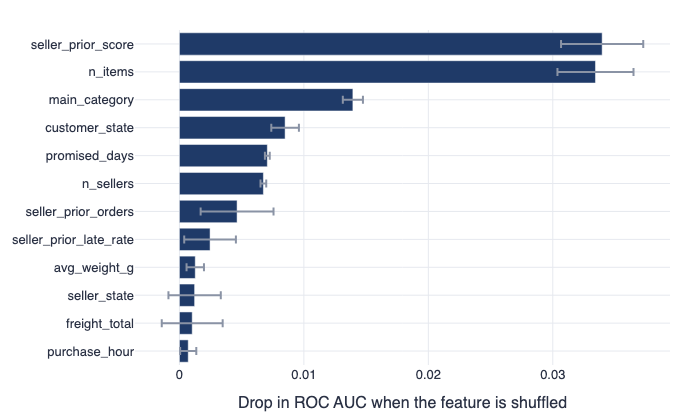

In [4]:
imp = pd.read_csv(C.TABLE_DIR / 'model_importance.csv')
V.fig_importance(imp, 'at_risk')

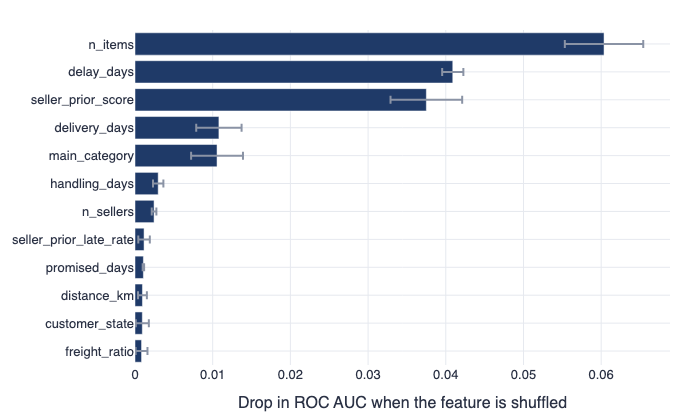

In [5]:
V.fig_importance(imp, 'post_hoc')

Comparing the two importance charts is the most informative thing in this section.

The post-hoc model's second-strongest feature is **`delay_days`**, how late the order
actually was. The at-risk model does not have it, cannot have it, and that single absence is
most of the gap between 0.73 and 0.63 AUC.

**That gap is the entire project in one observation.** The variable that overwhelmingly
determines whether a customer is satisfied does not exist at the moment of sale. It is
created later, by the carrier. Which is why the recommendations that follow are about
logistics and not about better targeting, ranking or merchandising. You cannot predict your
way out of this, you have to fix the delivery.

What the at-risk model *can* see is mostly structural: the seller's prior track record, the
number of items, the category, the customer's state, and the promised delivery window. All
things notebooks 01 and 02 already flagged.

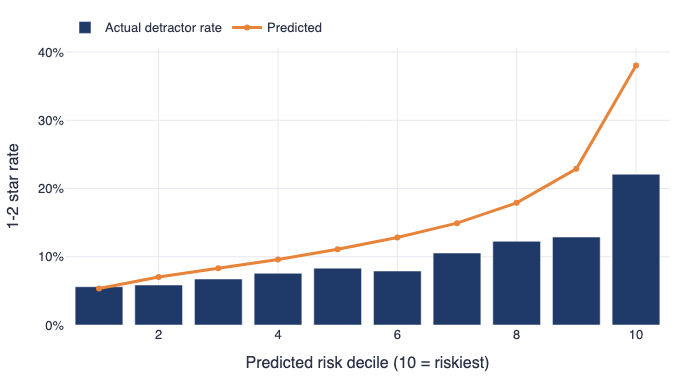

In [6]:
V.fig_calibration(pd.read_csv(C.TABLE_DIR / 'model_calibration.csv'))

The calibration chart makes the same point visually. The bars climb monotonically from the
safest decile to the riskiest, which is the ranking working. The predicted line is much
flatter than the actual bars, which is the calibration failing: the model is directionally
right and numerically timid, under-predicting at the risky end and over-predicting at the
safe end.

For a triage queue, the bars are what matter and this is fine. For anything customer-facing,
it is not.

---
# 2. A verdict for every seller, not just a score

The brief's fear is that removing weak sellers shrinks the catalogue and stalls growth.
That is a testable claim rather than a matter of opinion, and testing it is more useful than
arguing about it.

Every seller is scored on two independent axes: do they sell decent products, and do they
deliver on time. That produces four quadrants and four different responses. A seller who
sells good products late needs help, not punishment; a seller who sells bad products on
time needs a different conversation entirely. Collapsing both axes into one average score
loses exactly the distinction that decides what to do.

We only judge sellers with **30 or more orders**. Below that, one unlucky customer swings the
average and you would be delisting people for noise.

In [7]:
sc = A.seller_scorecard(base, baseline)
rated = sc[sc.orders >= C.SELLER_MIN_ORDERS]

verdicts = pd.DataFrame({
    'sellers': sc.action.value_counts(),
    'gmv_share': sc.groupby('action').gmv.sum() / sc.gmv.sum(),
}).sort_values('gmv_share', ascending=False)
verdicts.round(4)

,sellers,gmv_share
action,,
Invest,439,0.5159
Monitor (low volume),2316,0.2312
Coach: fulfilment,156,0.2213
Coach: product quality,4,0.0177
Remove,16,0.0139


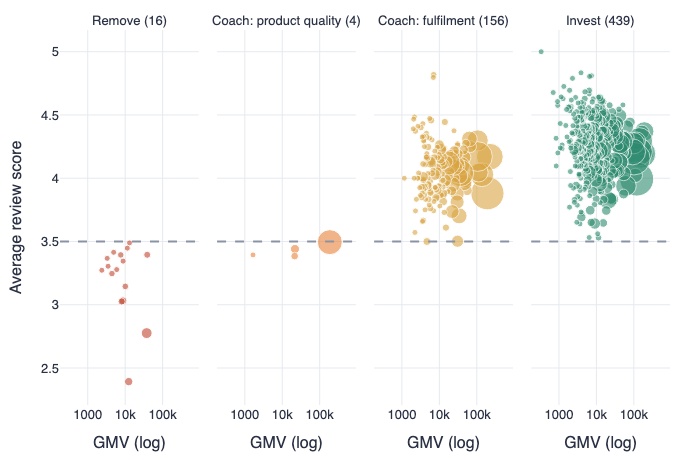

In [8]:
V.fig_seller_quadrant(sc)

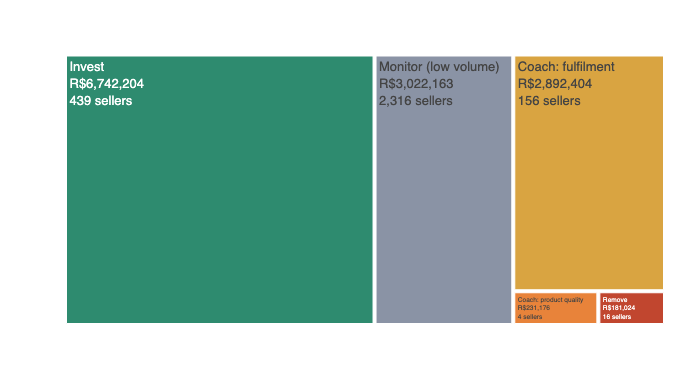

In [9]:
V.fig_action_treemap(sc)

**16 sellers fail on both counts. Between them they hold 1.4% of GMV.**

The catalogue-shrinkage fear turns out to be almost entirely unfounded at the irredeemable
end. Every one of them could be delisted tomorrow at a cost of about one part in seventy of
revenue.

The more interesting group is the **156 sellers who deliver late while selling perfectly good
products**. They are 22% of GMV. Delisting those would be self-harm, and given section 3 of
notebook 02, a good part of their lateness is not even theirs; it belongs to the carrier
collecting from them. They need pickup scheduling and carrier support, not a warning letter.

So the recommendation splits cleanly: **remove 16, coach 156.** That is a far more precise
answer than "crack down on slow sellers", and it costs a fraction as much.

---
# 3. What would each fix actually cost?

The final step is to put numbers against the options. Rather than assuming an effect size,
we fit the real observed relationship between lateness and detractor risk, then replay the
actual order history with each lever applied and read off the new detractor count.

That makes these estimates *magnitudes* rather than forecasts, which is the honest framing:
they are good enough to rank the options against each other and not precise enough to budget
from to two decimal places.

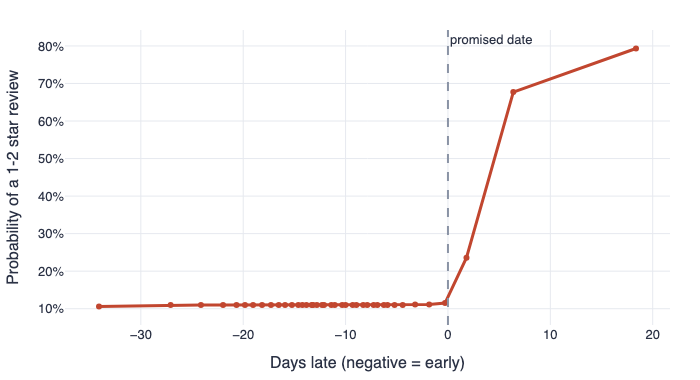

In [10]:
curve = S.fit_delay_curve(base)
V.fig_sim_curve(curve)

This is the curve every number below rests on. It is the same cliff from notebook 02,
fitted as a continuous function of days late rather than in buckets, and constrained to be
monotone: risk is not allowed to fall as an order gets later.

The flat left half is the important part for the promise question. Detractor risk is
essentially constant while an order is early, then climbs steeply from the promised date
onward. There is no reward for being very early and a severe penalty for being late, which
is precisely why moving the promised date is such a consequential lever.

In [11]:
rows = []
for name, preset in S.preset_scenarios().items():
    r = S.run(base, preset, curve)
    rows.append({
        'scenario': name,
        'detractors_avoided': round(r['detractors_avoided']),
        'pct_of_detractors': round(r['detractors_avoided_pct'] * 100, 1),
        'orders_lost': round(r['orders_lost']),
        'sellers_removed': r['sellers_removed'],
        'gmv_lost': round(r['gmv_lost']),
        'late_rate_after': round(r['after']['late_rate'], 4),
        'net_value': round(r['net_value']),
    })
scenarios = pd.DataFrame(rows)
scenarios

,scenario,detractors_avoided,pct_of_detractors,orders_lost,sellers_removed,gmv_lost,late_rate_after,net_value
0,Do nothing,0,0.0,0,0,0,0.0801,0
1,Fix the worst lanes,835,6.1,0,0,0,0.0642,114150
2,Remove the worst sellers,400,2.9,2295,20,412200,0.0787,-357496
3,Tighten the promise by 3 days,-1639,-12.0,0,0,0,0.1293,-224221
4,Combined programme,355,2.6,2295,20,412200,0.0914,-363603


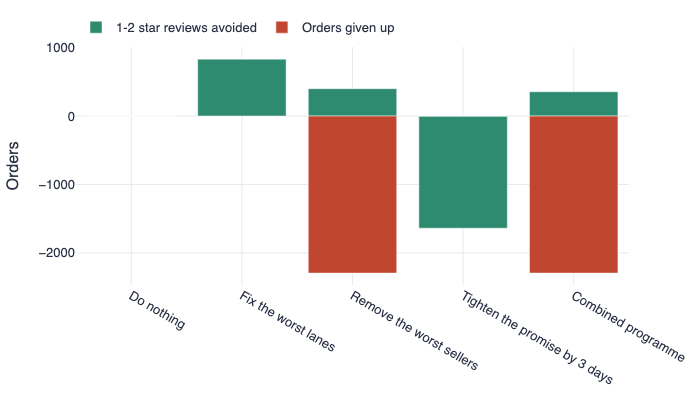

In [12]:
V.fig_scenario_compare(scenarios)

### The one we did not see coming

Look at the promise row. **Shortening the delivery promise by three days makes things
significantly worse**. It creates roughly 1,600 additional detractors and pushes the late
rate from 8% to nearly 13%.

We had assumed the opposite. The median order is promised in 23 days and arrives in 10,
which looks like obvious sandbagging, and the instinct was that tightening it would build
trust at checkout for free. But section 4 of notebook 02 showed the padding is not waste. It is the only thing absorbing the variance in a transit network that occasionally takes a
month. Remove it and orders that were quietly fine become officially late, and the cliff
does the rest.

The sequencing falls straight out of that: **buy the speed first, then spend it on a shorter
promise.** Not the other way round. The padding is a budget and it is already committed.

### And the one that is genuinely free

**Fixing the worst lanes avoids around 835 detractors and costs no revenue at all.** It is
the only lever here with unambiguously positive net value, and it should be funded before
anything else. It is also the most concrete: notebook 02 named São Paulo to Rio de Janeiro
as the single worst lane in the marketplace.

### And the one that is genuinely a judgement call

Removing weak sellers is more marginal than section 2 suggested on its own. It avoids around
400 detractors but gives up **R$412k of GMV**. At a valuation of one average order per lost
customer, that does not pay.

In [13]:
r = S.run(base, S.Scenario(remove_below_score=3.5), curve)
aov = r['baseline']['gmv'] / r['baseline']['orders']
breakeven = r['gmv_lost'] / (r['detractors_avoided'] * aov)

print(f"Average order value : R$ {aov:,.2f}")
print(f"Detractors avoided  : {r['detractors_avoided']:,.0f}")
print(f"Sellers removed     : {r['sellers_removed']:,}")
print(f"GMV given up        : R$ {r['gmv_lost']:,.0f}")
print()
print(f"Delisting pays once a lost customer is worth more than {breakeven:.1f}x one order.")

Average order value : R$ 136.76
Detractors avoided  : 400
Sellers removed     : 20
GMV given up        : R$ 412,200

Delisting pays once a lost customer is worth more than 7.5x one order.


Two details in that output are worth not skating past.

**The scenario removes 20 sellers, but section 2's verdict list had 16.** They are different
questions, deliberately. The scenario delists on the score axis alone: every rated seller
averaging under 3.5 stars. The verdict requires failing on *both* axes, quality and delivery.
The four sellers in the gap sell poorly-rated products but ship them on time, which is a
coaching problem rather than a removal one. It is a small discrepancy and it is exactly the
kind that quietly becomes a wrong headline if nobody reconciles it.

**The breakeven is far higher than we expected.** Delisting only pays once a lost customer
is worth more than **7.5 average orders**, not the two or three that would make this an easy
call. At R$136.76 per order that is roughly R$1,025 of lifetime value per customer, in a
marketplace where only 3.1% of customers ever come back at all. On this dataset's own
evidence, that threshold is very unlikely to be met.

So we are not going to give a yes or no on delisting; the honest output is the threshold
itself. Whoever owns customer lifetime value knows that number far better than this dataset
does, and handing them a threshold is more useful than handing them a verdict built on an
assumption we invented. But our reading of the evidence is that **coaching wins for almost
everybody**, and removal should be reserved for the 16 who fail on both axes.

---
# 4. Recommendations

**On the original question:** growth and customer experience are not opposed across the
board. They are opposed in specific, nameable places, and most of the fixes cost far less
than the framing of the brief assumes.

**What we would do, in order:**

1. **Fund carrier speed on the worst lanes.** The only move that improves experience while
   giving up no revenue at all. Start with São Paulo → Rio de Janeiro, which is
   high-volume, short-haul, and by some distance the worst-performing lane in the country.
2. **Leave the delivery promise alone** until transit times have actually fallen. It is
   protecting the on-time rate, not padding a metric. Revisit it only after step 1 lands.
3. **Coach 156 sellers, remove 16.** The removal list is 1.4% of GMV. The coaching list is
   22%, and a good part of their lateness belongs to the carrier rather than to them.
4. **Fix split shipments.** 1.3 stars lost on 1.3% of orders, the cheapest item on this
   list. Either consolidate fulfilment or set expectations per parcel at checkout.
5. **Look at the refund and service process.** 16% of complaints, untouched by any
   logistics investment, and owned by a different team.

**What would change our answer:**

*Lateness is treated as causal.* The curve is steep and monotone, and the review text agrees
independently, which is why we are comfortable, but some of the effect could be proxying
for correlated problems such as poor seller communication. The scenario numbers are
magnitudes, not forecasts.

*A detractor is valued at one average order.* A floor, deliberately, justified by the 3.1%
repeat-purchase rate in notebook 01. It ignores word of mouth entirely, which is exactly why
we reported the breakeven threshold rather than a verdict.

*Removed sellers are treated as lost demand.* In practice some of those customers would be
recaptured by other sellers on the platform, so the cost of delisting shown here is a
worst case.

*The data ends in October 2018.* The absolute levels have moved since. The *relationships*
between distance, lateness and satisfaction are considerably more durable than the levels.

**The single field we would most want:** carrier identity. It is not in this dataset, and it
would turn "the carrier is slow" into "*this* carrier is slow on *this* lane", which is the
difference between an observation and something operations can act on Monday morning.

---

*The interactive dashboard in `app/` carries these findings forward: the segment views can
be explored rather than read, and the scenario levers in section 3 can be moved by the
people who would have to fund them.*